## 46-881 Class 3 - Discussion Session

### Python Programming: Syntax and Data Structures (Part 1)

Amr Farahat

CMU / Tepper

2022-11-09

---



## 1. Quick review of syntax elements

### The "if else" statement

In [1]:
# Example 
temp = 75 

if temp > 60:
    print("do not bring jacket")
elif temp > 35:
    print("bring jacket")
elif temp > 20:    
    print("bring winter coat")
else:
    print("do not leave house")
    
# pretty subjective though!    

do not bring jacket


### The "for" statement

In [2]:
for i in range(5):
    print(i**2)

0
1
4
9
16


In [3]:
day_list = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for i in day_list:
    print("Today is", i)
    if i == "Wed":
        print("Hooray, Programming Day!")

Today is Mon
Today is Tue
Today is Wed
Hooray, Programming Day!
Today is Thu
Today is Fri
Today is Sat
Today is Sun


### Importing libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### Using random numbers

In [48]:
rng = np.random.default_rng()
x = []
for i in range(1000): 
    x.append(rng.uniform(1, 10))

In [49]:
# Equivalently:
#rng = np.random.default_rng()
#x = rng.uniform(1, 10, size = 1000)

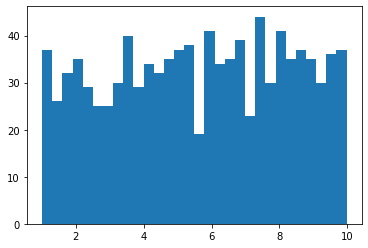

In [50]:
plt.hist(x, bins=30)
plt.show()

## 2. Solving the order quantity problem

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
unit_price = 10
unit_cost = 5
unit_salvage_value = 3

Let's assume that demand follows a *Binomial distribution* with the following parameters:

In [72]:
n = 400
p = 0.25

## Two questions that we'll attempt to answer:

1. What is the expected profit corresponding to some order quantity
2. What is the order quantity that maximizes expected profit?

In [121]:
unit_price = 10
unit_cost = 5
unit_salvage_value = 3
order_quantity = 120
demand = 104
total_cost = unit_cost * order_quantity 
if demand <= order_quantity:
    units_sold = demand
    units_salvaged = order_quantity - demand
else:  
    units_sold = order_quantity
    units_salvaged = 0 
        
sales_revenue = unit_price * units_sold
salvage_revenue = unit_salvage_value * units_salvaged
total_revenue = sales_revenue + salvage_revenue

profit = total_revenue - total_cost

print('sales_revenue:', sales_revenue)
print('salvage_revenue:',salvage_revenue)
print('total_cost:', total_cost)
print('total_revenue:',total_revenue)
print('profit:',profit)

sales_revenue: 1040
salvage_revenue: 48
total_cost: 600
total_revenue: 1088
profit: 488


In [172]:
order_quantity_list = list(range(80,85,1))
expected_profit_list = []
for order_quantity in order_quantity_list:
    profit_list = []
    rng = np.random.default_rng()
    for i in range(5):
        demand = rng.binomial(n, p)
        #print(demand)
        total_cost = unit_cost * order_quantity 
        if demand <= order_quantity:
            units_sold = demand
            units_salvaged = order_quantity - demand
        else:  
            units_sold = order_quantity
            units_salvaged = 0 
        
        sales_revenue = unit_price * units_sold
        salvage_revenue = unit_salvage_value * units_salvaged
        total_revenue = sales_revenue + salvage_revenue

        profit = total_revenue - total_cost
        profit_list.append(profit)
        print(order_quantity,i,demand, profit)

    expected_profit_list.append(np.mean(profit_list))

    print(expected_profit_list)

80 0 97 400
80 1 100 400
80 2 98 400
80 3 101 400
80 4 86 400
[400.0]
81 0 93 405
81 1 92 405
81 2 93 405
81 3 109 405
81 4 91 405
[400.0, 405.0]
82 0 97 410
82 1 115 410
82 2 110 410
82 3 118 410
82 4 101 410
[400.0, 405.0, 410.0]
83 0 76 366
83 1 99 415
83 2 104 415
83 3 94 415
83 4 99 415
[400.0, 405.0, 410.0, 405.2]
84 0 93 420
84 1 97 420
84 2 98 420
84 3 105 420
84 4 95 420
[400.0, 405.0, 410.0, 405.2, 420.0]


In [173]:
max_profit = np.max(expected_profit_list)
optimal_quantity = order_quantity_list[expected_profit_list.index(max_profit)]
print("Ordering", optimal_quantity, "units yields the optimal profit of", max_profit, "dollars.")

Ordering 84 units yields the optimal profit of 420.0 dollars.


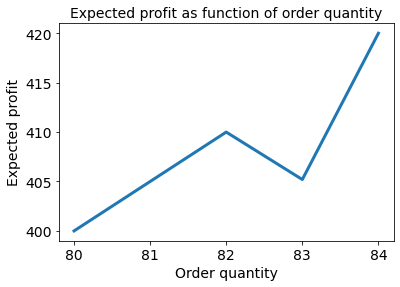

In [174]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(order_quantity_list, expected_profit_list, linewidth=3)
ax.set_title("Expected profit as function of order quantity", fontsize = 14)
ax.set_xlabel("Order quantity", fontsize=14)
ax.set_ylabel("Expected profit", fontsize=14)
ax.tick_params(axis='both', labelsize = 14)

## 3. Extending the order quantity problem - price optimization

Suppose the probability of buying the product (the Binomial parameter, p) varies linearly with the unit price: p = 1 - 0.075 * unit_price. 

Other problem parameters are unchanged.

**Find the optimal unit price**.

For simplicity, consider only prices in range(8,14,1) and order quantities in range(80,181,5).

*Same code from Section 2 above is repeated below as starting template*:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
unit_price = 10
unit_cost = 5
unit_salvage_value = 3

Let's assume that demand follows a *Binomial distribution* with the following parameters:

In [ ]:
n = 400
p = 0.25

In [ ]:
order_quantity_list = list(range(80,121,1))
expected_profit_list = []
for order_quantity in order_quantity_list:
    profit_list = []
    rng = np.random.default_rng(seed=881)
    for i in range(10000):
        demand = rng.binomial(n, p)
        total_cost = unit_cost * order_quantity 
        if demand <= order_quantity:
            units_sold = demand
            units_salvaged = order_quantity - demand
        else:  
            units_sold = order_quantity
            units_salvaged = 0 
        
        sales_revenue = unit_price * units_sold
        salvage_revenue = unit_salvage_value * units_salvaged
        total_revenue = sales_revenue + salvage_revenue

        profit = total_revenue - total_cost
        profit_list.append(profit)

    expected_profit_list.append(np.mean(profit_list))

In [ ]:
print(expected_profit_list)

In [ ]:
max_profit = np.max(expected_profit_list)
optimal_quantity = order_quantity_list[expected_profit_list.index(max_profit)]
print("Ordering", optimal_quantity, "units yields the optimal profit of", max_profit, "dollars.")

---
### END